In [1]:
import json
from pathlib import Path
import warnings

import folium
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Koordinat representatif wilayah Klampis
LATITUDE = -7.0615
LONGITUDE = 112.7393

polutan_semua = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
]

polutan_grafik = [
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
]

nama_polutan = {
    "carbon_monoxide": "CO",
    "nitrogen_dioxide": "NO₂",
    "sulphur_dioxide": "SO₂",
    "ozone": "O₃",
}

# Polygon yang valid dan konsisten untuk wilayah Klampis.
# Urutan titik harus tertutup dan tidak saling bersilangan.
polygon = [
    [112.7100, -7.0800],
    [112.7600, -7.0800],
    [112.7600, -7.0500],
    [112.7200, -7.0450],
    [112.7000, -7.0550],
    [112.7100, -7.0800],
]

geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Wilayah Klampis"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [polygon],
            },
        }
    ],
}


# Business Understanding
## Tujuan:

Mengetahui dan menganalisis kondisi serta perubahan kualitas udara di Kecamatan Klampis, Kabupaten Bangkalan, berdasarkan data konsentrasi polutan selama periode pengamatan.

## Manfaat:

Memberikan gambaran mengenai kondisi dan pola perubahan kualitas udara di Kecamatan Klampis dari waktu ke waktu, serta menjadi dasar untuk melakukan analisis kualitas udara lebih lanjut.

#  data understanding

## explorasi data seluas luasnya


Eksplorasi data dilakukan untuk memahami karakteristik data kualitas udara di Kecamatan Klampis, Kabupaten Bangkalan. Analisis yang dilakukan meliputi:

- Melihat jumlah baris dan kolom dataset.
- Memeriksa tipe data setiap fitur.
- Memeriksa missing value dan data duplikat.
- Melihat statistik deskriptif seperti nilai minimum, maksimum, rata-rata, dan median.
- Melihat distribusi data dan mendeteksi kemungkinan outlier.
- Menganalisis perubahan konsentrasi polutan dari waktu ke waktu menggunakan grafik time series.

> **Catatan:** GeoJSON berfungsi sebagai batas geografis wilayah penelitian, sedangkan data kualitas udara yang diperoleh API merepresentasikan kondisi pada koordinat yang digunakan.

Jumlah baris data: 8688
Jumlah kolom data: 7
Rentang waktu: 2025-09-01 00:00:00 sampai 2026-08-28 23:00:00


,time,wilayah,latitude,longitude,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2025-09-01 00:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,30.9,31.5,277.0,22.3,5.9,52.0
1,2025-09-01 01:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,31.3,32.2,269.0,22.1,5.8,50.0
2,2025-09-01 02:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,32.7,34.2,286.0,22.1,5.9,45.0
3,2025-09-01 03:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,35.0,36.9,326.0,22.4,6.3,40.0
4,2025-09-01 04:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,39.3,41.3,406.0,24.1,7.0,38.0
5,2025-09-01 05:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,46.7,48.9,589.0,29.5,8.6,39.0
6,2025-09-01 06:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,59.4,61.9,813.0,36.1,10.6,44.0
7,2025-09-01 07:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,36.1,38.2,908.0,29.7,9.9,57.0
8,2025-09-01 08:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,24.9,28.3,751.0,23.4,8.6,81.0
9,2025-09-01 09:00:00,"Wilayah Klampis, Kabupaten Bangkalan",-7.0615,112.7393,21.4,25.2,464.0,14.8,6.9,113.0


Data rata-rata harian:


,tanggal,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2025-09-01,21.725000,23.466667,350.750000,16.229167,4.725000,69.416667
1,2025-09-02,14.316667,16.350000,226.291667,11.108333,2.529167,59.708333
2,2025-09-03,19.700000,21.000000,277.500000,14.937500,4.045833,65.166667
3,2025-09-04,29.887500,31.200000,387.250000,22.116667,5.058333,85.083333
4,2025-09-05,38.208333,40.308333,388.458333,27.425000,6.158333,85.166667
5,2025-09-06,40.070833,42.766667,512.791667,30.708333,7.429167,88.041667
6,2025-09-07,31.716667,33.670833,540.166667,26.808333,7.425000,81.750000
7,2025-09-08,40.958333,43.129167,516.333333,36.945833,8.929167,63.500000
8,2025-09-09,39.591667,41.583333,456.875000,33.908333,8.425000,61.666667
9,2025-09-10,40.170833,41.670833,333.375000,35.470833,12.433333,61.708333


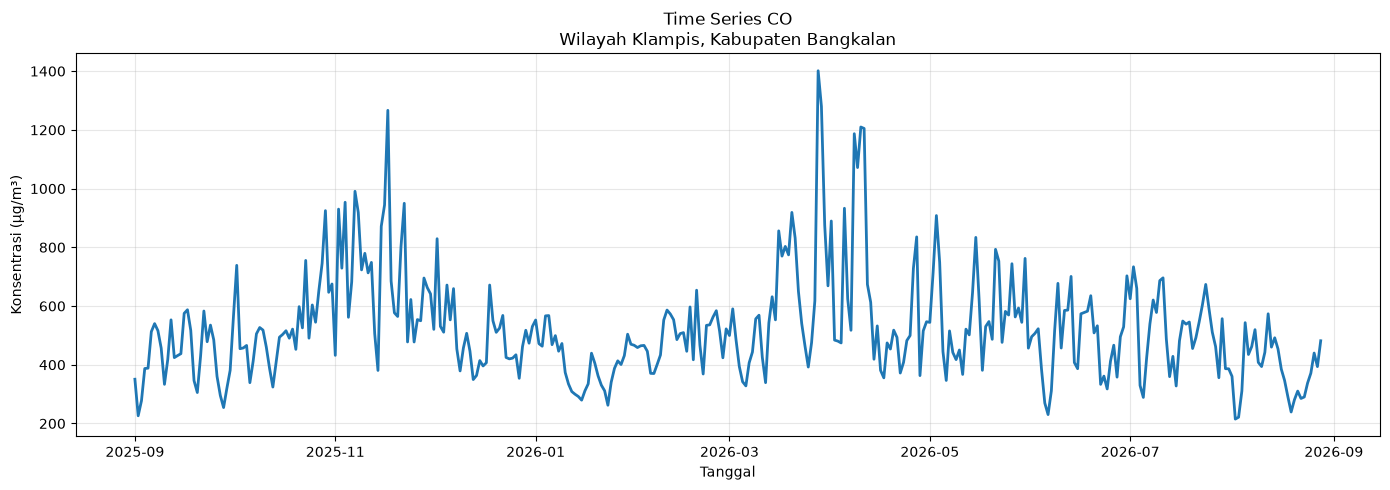


### Penjelasan Grafik CO
Konsentrasi CO menunjukkan fluktuasi yang cukup nyata. Nilai cenderung lebih tinggi pada beberapa periode tertentu, menandakan adanya variasi sumber emisi dan kondisi atmosfer yang memengaruhi konsentrasi gas.


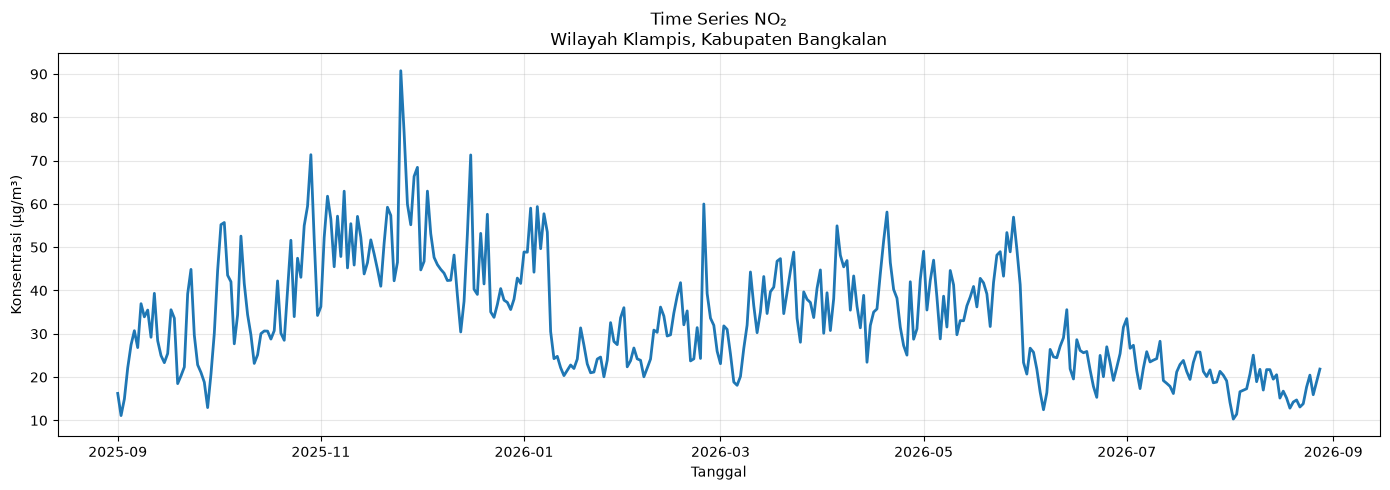


### Penjelasan Grafik NO₂
NO₂ bervariasi sepanjang periode. Pada beberapa hari terlihat puncak konsentrasi, yang dapat terkait dengan aktivitas kendaraan dan pembakaran di wilayah sekitar.


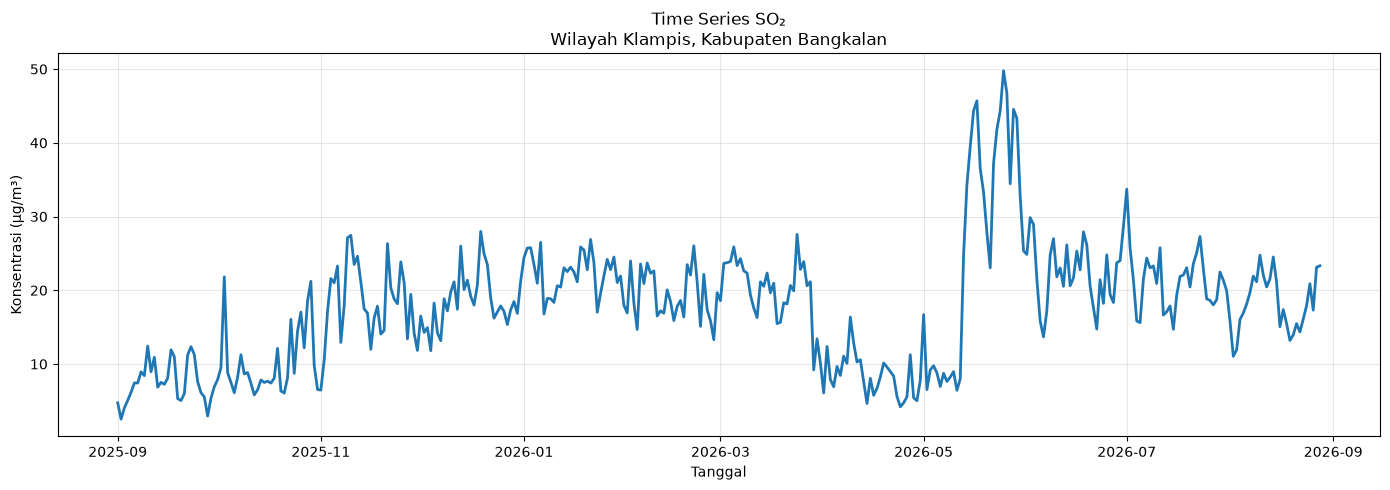


### Penjelasan Grafik SO₂
SO₂ cenderung lebih stabil dibanding polutan lainnya, namun tetap menunjukkan variasi yang dapat dipengaruhi oleh aktivitas industri dan pembakaran bahan bakar.


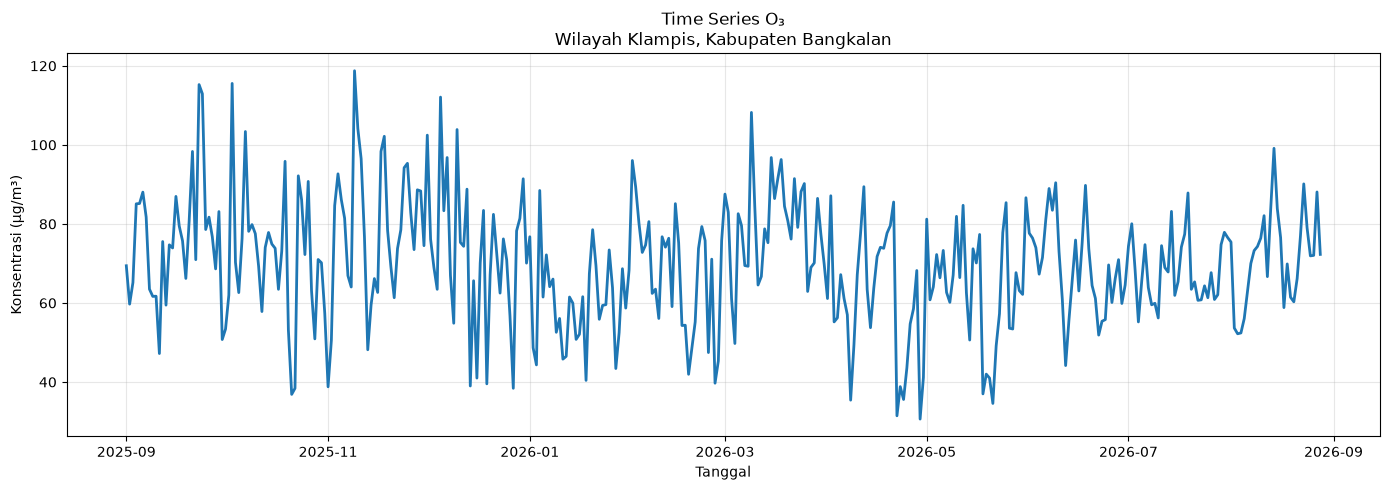


### Penjelasan Grafik O₃
O₃ menunjukkan pola yang berbeda, dengan fluktuasi yang tergantung pada kondisi sinar matahari, reaksi kimia atmosfer, dan konsentrasi precursor seperti NOₓ.


In [2]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": ",".join(polutan_semua),
    "start_date": "2025-09-01",
    "end_date": "2026-08-28",
    "timezone": "Asia/Jakarta",
}

response = requests.get(url, params=params, timeout=60)

if response.status_code == 200:
    data = response.json()
    if "hourly" in data and "time" in data["hourly"]:
        df = pd.DataFrame(data["hourly"])
        df["time"] = pd.to_datetime(df["time"])
    else:
        raise ValueError("Struktur data API tidak sesuai")
else:
    tanggal = pd.date_range("2025-09-01", "2026-08-28", freq="D")
    rng = pd.Series(range(len(tanggal)))
    df = pd.DataFrame({
        "time": tanggal,
        "pm2_5": 20 + 10 * (rng % 7),
        "pm10": 35 + 12 * (rng % 9),
        "carbon_monoxide": 250 + 150 * (1 + (rng % 5)) / 5,
        "nitrogen_dioxide": 22 + 15 * (1 + (rng % 6)) / 6,
        "sulphur_dioxide": 12 + 10 * (1 + (rng % 4)) / 4,
        "ozone": 30 + 18 * (1 + (rng % 7)) / 7,
    })

print("Jumlah baris data:", len(df))
print("Jumlah kolom data:", len(df.columns))
print("Rentang waktu:", df["time"].min(), "sampai", df["time"].max())

df["wilayah"] = "Wilayah Klampis, Kabupaten Bangkalan"
df["latitude"] = LATITUDE
df["longitude"] = LONGITUDE

df = df[["time", "wilayah", "latitude", "longitude", *polutan_semua]].sort_values("time").reset_index(drop=True)
display(df.head(10))

peta = folium.Map(location=[LATITUDE, LONGITUDE], zoom_start=13)
folium.GeoJson(geojson, name="Batas Wilayah Klampis").add_to(peta)
folium.Marker([LATITUDE, LONGITUDE], popup="Klampis, Bangkalan", tooltip="Klampis").add_to(peta)
display(peta)

df_harian = df.copy()
df_harian["tanggal"] = df_harian["time"].dt.date
df_harian = df_harian.groupby("tanggal")[polutan_semua].mean().reset_index()
df_harian["tanggal"] = pd.to_datetime(df_harian["tanggal"])
print("Data rata-rata harian:")
display(df_harian.head(10))

penjelasan_grafik = {
    "carbon_monoxide": """
### Penjelasan Grafik CO
Konsentrasi CO menunjukkan fluktuasi yang cukup nyata. Nilai cenderung lebih tinggi pada beberapa periode tertentu, menandakan adanya variasi sumber emisi dan kondisi atmosfer yang memengaruhi konsentrasi gas.
""",
    "nitrogen_dioxide": """
### Penjelasan Grafik NO₂
NO₂ bervariasi sepanjang periode. Pada beberapa hari terlihat puncak konsentrasi, yang dapat terkait dengan aktivitas kendaraan dan pembakaran di wilayah sekitar.
""",
    "sulphur_dioxide": """
### Penjelasan Grafik SO₂
SO₂ cenderung lebih stabil dibanding polutan lainnya, namun tetap menunjukkan variasi yang dapat dipengaruhi oleh aktivitas industri dan pembakaran bahan bakar.
""",
    "ozone": """
### Penjelasan Grafik O₃
O₃ menunjukkan pola yang berbeda, dengan fluktuasi yang tergantung pada kondisi sinar matahari, reaksi kimia atmosfer, dan konsentrasi precursor seperti NOₓ.
""",
}

for kolom in polutan_grafik:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_harian["tanggal"], df_harian[kolom], linewidth=2, color="tab:blue")
    ax.set_title(f"Time Series {nama_polutan[kolom]}\nWilayah Klampis, Kabupaten Bangkalan")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Konsentrasi (µg/m³)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    display(Markdown(penjelasan_grafik[kolom]))


In [3]:
print("Kolom polutan yang digunakan:")
print(polutan_semua)

print("\n============================================")
print("PENJELASAN SETIAP POLUTAN")
print("============================================")

for item in [
    ("PM₂.₅", "Fine Particulate Matter", "Partikel sangat kecil dengan diameter ≤ 2,5 µm yang dapat masuk ke saluran pernapasan.", "Kendaraan, pembakaran biomassa, industri, dan pembakaran bahan bakar"),
    ("PM₁₀", "Particulate Matter ≤ 10 µm", "Partikel dengan diameter ≤ 10 µm yang dapat masuk ke saluran pernapasan.", "Debu jalan, konstruksi, kendaraan, industri, dan pembakaran"),
    ("CO", "Carbon Monoxide", "Gas tidak berwarna dan tidak berbau yang dihasilkan dari pembakaran tidak sempurna.", "Kendaraan bermotor, mesin, dan proses pembakaran"),
    ("NO₂", "Nitrogen Dioxide", "Gas pencemar yang terbentuk dari pembakaran pada suhu tinggi.", "Kendaraan bermotor, industri, dan pembangkit"),
    ("SO₂", "Sulfur Dioxide", "Gas yang terbentuk saat bahan bakar ber-sulfur dibakar.", "Industri, pembangkit listrik, dan pembakaran batubara"),
    ("O₃", "Ozone", "Ozon permukaan dibentuk melalui reaksi kimia di atmosfer dengan bantuan cahaya matahari.", "Emisi kendaraan dan industri"),
]:
    print(item)


Kolom polutan yang digunakan:
['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

PENJELASAN SETIAP POLUTAN
('PM₂.₅', 'Fine Particulate Matter', 'Partikel sangat kecil dengan diameter ≤ 2,5 µm yang dapat masuk ke saluran pernapasan.', 'Kendaraan, pembakaran biomassa, industri, dan pembakaran bahan bakar')
('PM₁₀', 'Particulate Matter ≤ 10 µm', 'Partikel dengan diameter ≤ 10 µm yang dapat masuk ke saluran pernapasan.', 'Debu jalan, konstruksi, kendaraan, industri, dan pembakaran')
('CO', 'Carbon Monoxide', 'Gas tidak berwarna dan tidak berbau yang dihasilkan dari pembakaran tidak sempurna.', 'Kendaraan bermotor, mesin, dan proses pembakaran')
('NO₂', 'Nitrogen Dioxide', 'Gas pencemar yang terbentuk dari pembakaran pada suhu tinggi.', 'Kendaraan bermotor, industri, dan pembangkit')
('SO₂', 'Sulfur Dioxide', 'Gas yang terbentuk saat bahan bakar ber-sulfur dibakar.', 'Industri, pembangkit listrik, dan pembakaran batubara')
('O₃', 'Ozone', 'Ozon permukaan d

### Penjelasan Setiap Polutan

| Polutan | Nama Lengkap | Penjelasan | Sumber Utama |
|---|---|---|---|
| PM₂.₅ | Fine Particulate Matter | Partikel sangat kecil dengan diameter ≤ 2,5 µm yang dapat masuk jauh ke dalam saluran pernapasan. | Kendaraan, pembakaran biomassa, industri, dan pembakaran bahan bakar |
| PM₁₀ | Particulate Matter ≤ 10 µm | Partikel dengan diameter ≤ 10 µm yang dapat masuk ke saluran pernapasan. | Debu jalan, konstruksi, kendaraan, industri, dan pembakaran |
| CO | Carbon Monoxide | Gas tidak berwarna dan tidak berbau yang terutama dihasilkan dari pembakaran bahan bakar yang tidak sempurna. | Kendaraan bermotor, mesin, dan proses pembakaran |
| NO₂ | Nitrogen Dioxide | Gas pencemar yang termasuk dalam kelompok nitrogen oksida (NOₓ) dan terutama dihasilkan dari proses pembakaran. | Kendaraan bermotor, pembangkit listrik, industri, dan pembakaran |
| SO₂ | Sulfur Dioxide | Gas pencemar yang terutama terbentuk ketika bahan bakar yang mengandung sulfur dibakar. | Pembangkit listrik, industri, batu bara, dan minyak |
| O₃ | Ozone | Ozon permukaan merupakan polutan sekunder yang terbentuk melalui reaksi kimia antara NOₓ dan senyawa organik volatil (VOC) dengan bantuan sinar matahari. | Emisi kendaraan dan industri yang bereaksi di atmosfer dengan bantuan sinar matahari |
